# GLIMMER on AZT1D and OhioT1DM: findings

*A pre-rendered summary assembled from notebooks 01-06 -- every plot and table here is copied output, not recomputed. This notebook is not meant to be re-run top to bottom (it draws on six separate kernel sessions and would error if executed fresh). For the full detailed record, including methodology and every intermediate step, see notebooks 01-06.*

## Table of contents

1. [The dataset](#1-the-dataset)
2. [What the data actually shows](#2-what-the-data-actually-shows)
3. [A simple baseline](#3-a-simple-baseline)
4. [Weighting the loss toward danger zones](#4-weighting-the-loss-toward-danger-zones)
5. [Does that trade-off matter clinically](#5-does-that-trade-off-matter-clinically)
6. [Tuning the weights per patient](#6-tuning-the-weights-per-patient)
7. [Testing it on a second dataset](#7-testing-it-on-a-second-dataset)
8. [Bottom line](#8-bottom-line)

## 1. The dataset

*Who this data is about, and whether it's trustworthy enough to build on.*

AZT1D is real-world data from 25 people with type 1 diabetes, each already using an automated insulin delivery system: a continuous glucose monitor (Dexcom G6 Pro) paired with an insulin pump (Tandem t:slim X2) that automatically adjusts insulin based on glucose trends. Researchers at Mayo Clinic Arizona pulled about a month of data per person straight off each patient's own pump and sensor during routine care between December 2023 and April 2024, with informed consent and ethics review board approval. It comes from a named, credentialed team, went through ethics review, and is published openly on Mendeley Data. Worth keeping in mind: it's brand new (2025), just 25 people from one clinic, and skews older (ages 27-80, averaging around 60) -- findings here describe this group well, not necessarily children or other populations without checking.

### Demographics

Table I from the paper (age, sex, A1c) is transcribed in `azt1d.reference.DEMOGRAPHICS_TABLE1`. Caveat: the paper's patient index is used here as `subject_id` provisionally -- this join hasn't been independently confirmed.

,subject_id,a1c_pct,sex,age
count,25.000000,25.00000,25,25.000000
unique,NaN,NaN,2,NaN
top,NaN,NaN,Female,NaN
freq,NaN,NaN,13,NaN
mean,13.000000,6.63600,NaN,59.200000
std,7.359801,0.71232,NaN,15.127238
min,1.000000,5.00000,NaN,27.000000
25%,7.000000,6.40000,NaN,46.000000
50%,13.000000,6.70000,NaN,65.000000
75%,19.000000,7.10000,NaN,69.000000


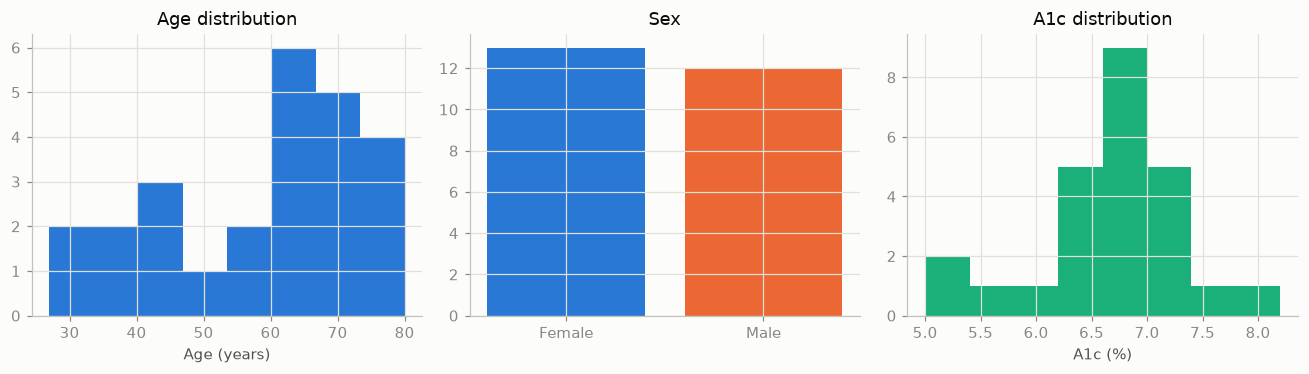

In [ ]:
demo = ref.DEMOGRAPHICS_TABLE1
display(demo.describe(include="all"))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(demo["age"], bins=8, color=plotting.CATEGORICAL[0])
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")

sex_counts = demo["sex"].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=plotting.CATEGORICAL[:len(sex_counts)])
axes[1].set_title("Sex")

axes[2].hist(demo["a1c_pct"], bins=8, color=plotting.CATEGORICAL[2])
axes[2].set_title("A1c distribution")
axes[2].set_xlabel("A1c (%)")

fig.tight_layout()
plt.show()


## 2. What the data actually shows

*The patterns in the raw data worth knowing before any modeling starts.*

**What's in each reading:** glucose (CGM, mg/dL, every 5 minutes; roughly 70-180 is the everyday target range), background ("basal") insulin (a steady trickle, U/hr), meal-time ("bolus") insulin (a one-time dose for food or to correct a high, in units), and carbs eaten at logged meals (grams).

### Glycemic control overview

Standard ambulatory glucose profile metrics per subject: time-in-range (70-180 mg/dL),
glucose management indicator (GMI, an estimated A1c from mean CGM), and coefficient of
variation (CV; >36% flags high glycemic variability).


In [ ]:
summary = metrics.summary_table(df)
display(summary)


CGM,hypo,in_range,hyper,gmi_pct,cv_pct,n_readings
subject_id,,,,,,
1,1.0,84.6,14.4,6.7,25.7,10881
2,0.3,74.6,25.1,7.0,28.3,11189
3,1.3,83.4,15.3,6.7,29.2,10685
4,0.1,63.1,36.8,7.4,31.1,12750
5,4.0,81.4,14.6,6.5,32.4,13052
6,0.1,85.2,14.7,6.7,22.8,12730
7,0.9,85.0,14.1,6.7,25.6,13385
8,0.5,68.1,31.3,7.1,31.3,8040
9,1.7,44.8,53.6,7.9,35.3,10674


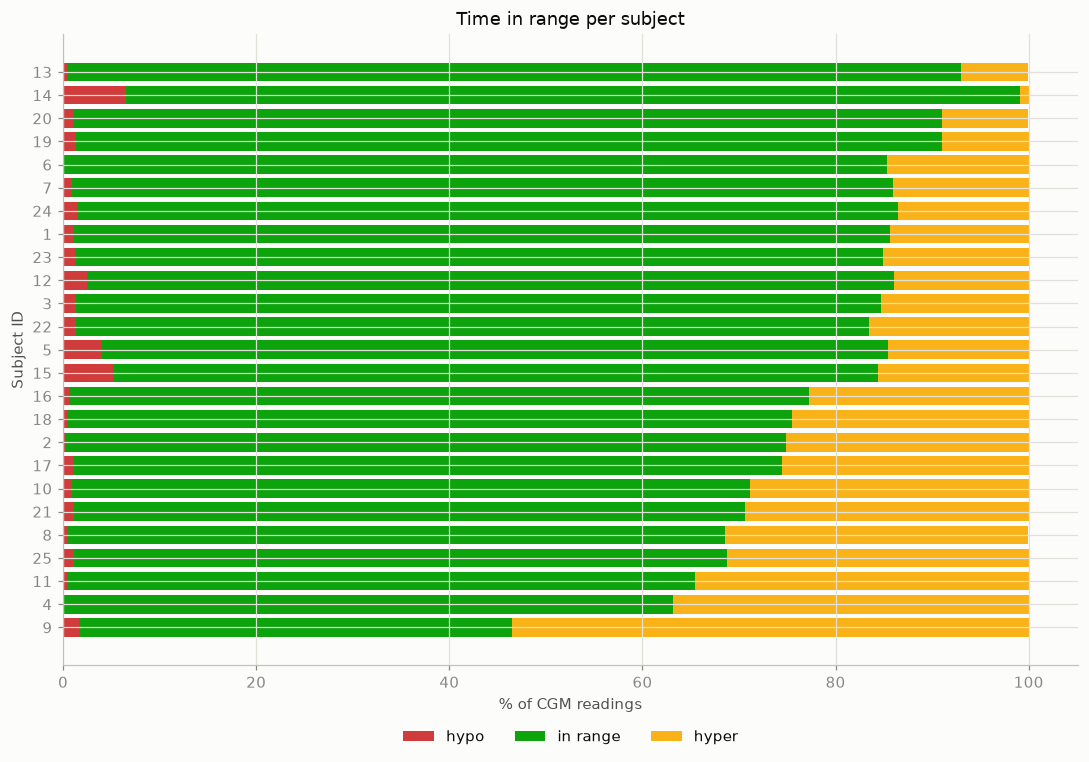

In [ ]:
ordered = summary.sort_values("in_range", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bottom = np.zeros(len(ordered))
for band in ["hypo", "in_range", "hyper"]:
    ax.barh(ordered.index.astype(str), ordered[band], left=bottom,
            color=plotting.GLUCOSE_BAND_COLORS[band], label=band.replace("_", " "))
    bottom += ordered[band].to_numpy()

ax.set_xlabel("% of CGM readings")
ax.set_ylabel("Subject ID")
ax.set_title("Time in range per subject" + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
fig.tight_layout()
plt.show()


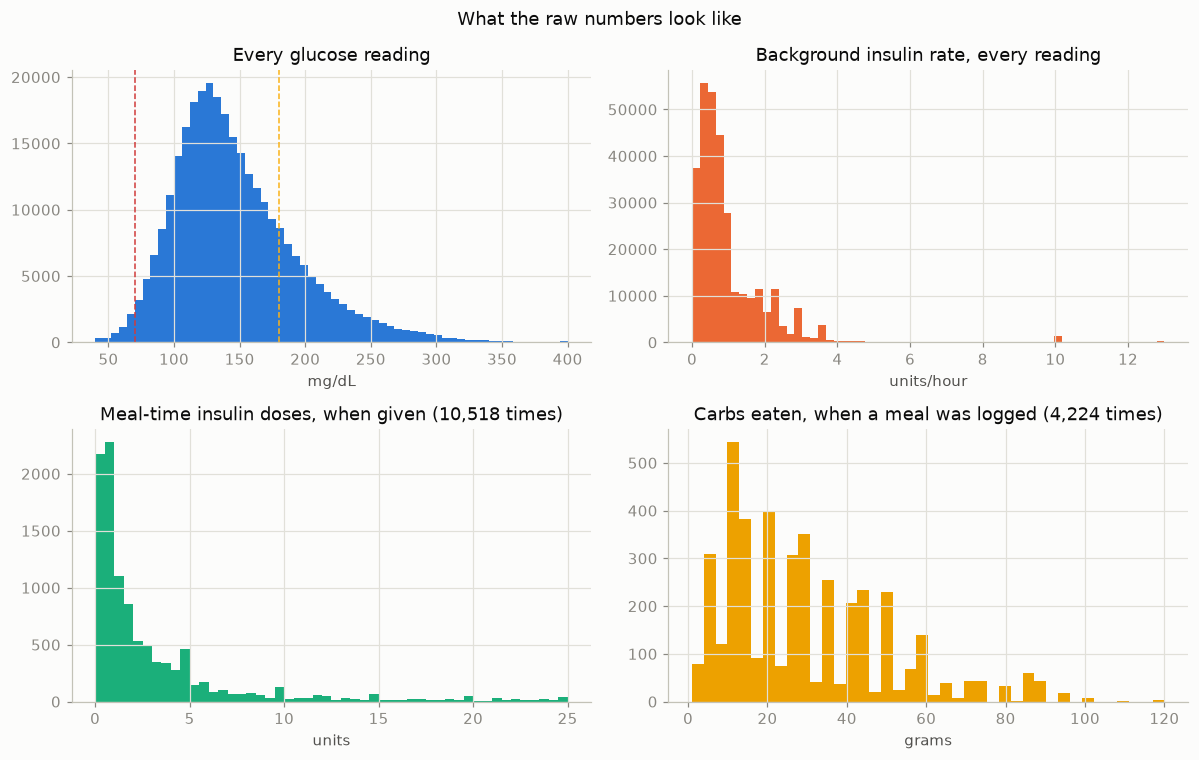

In [ ]:
bolus_doses = df.loc[df[ref.TOTAL_BOLUS_INSULIN_DELIVERED] > 0, ref.TOTAL_BOLUS_INSULIN_DELIVERED]
carb_sizes = df.loc[df[ref.CARB_SIZE] > 0, ref.CARB_SIZE]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].hist(df[ref.CGM], bins=60, color=plotting.CATEGORICAL[0])
axes[0, 0].axvline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
axes[0, 0].axvline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
axes[0, 0].set_title("Every glucose reading")
axes[0, 0].set_xlabel("mg/dL")

axes[0, 1].hist(df[ref.BASAL], bins=60, color=plotting.CATEGORICAL[1])
axes[0, 1].set_title("Background insulin rate, every reading")
axes[0, 1].set_xlabel("units/hour")

axes[1, 0].hist(bolus_doses, bins=50, color=plotting.CATEGORICAL[2])
axes[1, 0].set_title(f"Meal-time insulin doses, when given ({len(bolus_doses):,} times)")
axes[1, 0].set_xlabel("units")

axes[1, 1].hist(carb_sizes, bins=40, color=plotting.CATEGORICAL[3])
axes[1, 1].set_title(f"Carbs eaten, when a meal was logged ({len(carb_sizes):,} times)")
axes[1, 1].set_xlabel("grams")

fig.suptitle("What the raw numbers look like")
fig.tight_layout()
plt.show()


**Observation:** Glucose readings are not symmetric. There is a long tail toward high
values, not low ones. This makes sense for two reasons: patients and their pumps actively
try to avoid going low, since the immediate risks are more acute there, and glucose cannot
go below zero, so the low end has a hard floor the high end does not have.


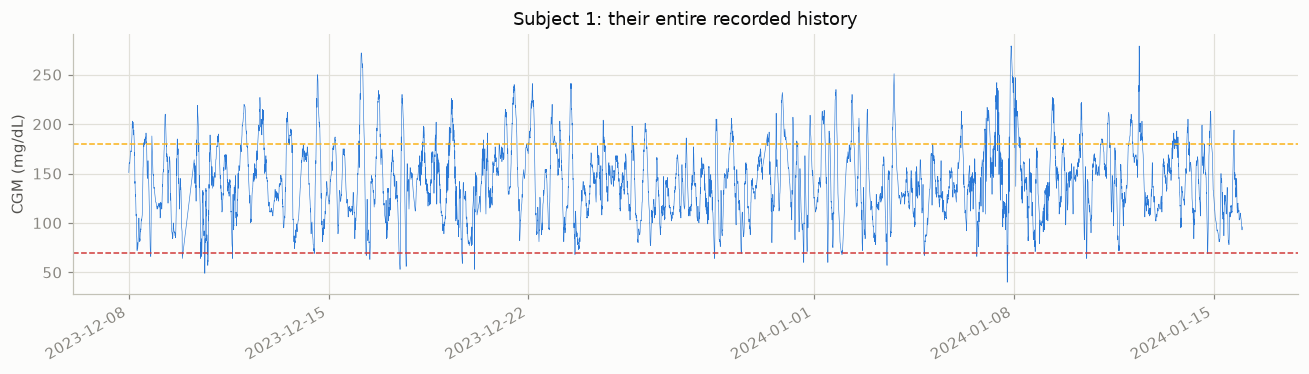

In [ ]:
example_full = df[df["subject_id"] == df["subject_id"].iloc[0]].sort_values(ref.EVENT_DATETIME)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(example_full[ref.EVENT_DATETIME], example_full[ref.CGM], color=plotting.CATEGORICAL[0], linewidth=0.4)
ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_ylabel("CGM (mg/dL)")
ax.set_title(f"Subject {int(example_full['subject_id'].iloc[0])}: their entire recorded history")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Observation:** The dashed lines mark the danger thresholds, low at the bottom and high
at the top. Subject 1 spent about 14% of their time above the high threshold and only
about 1% below the low threshold. That matches the whole cohort: 20% hyper versus 2%
hypo. Patients run high far more often than they run low.


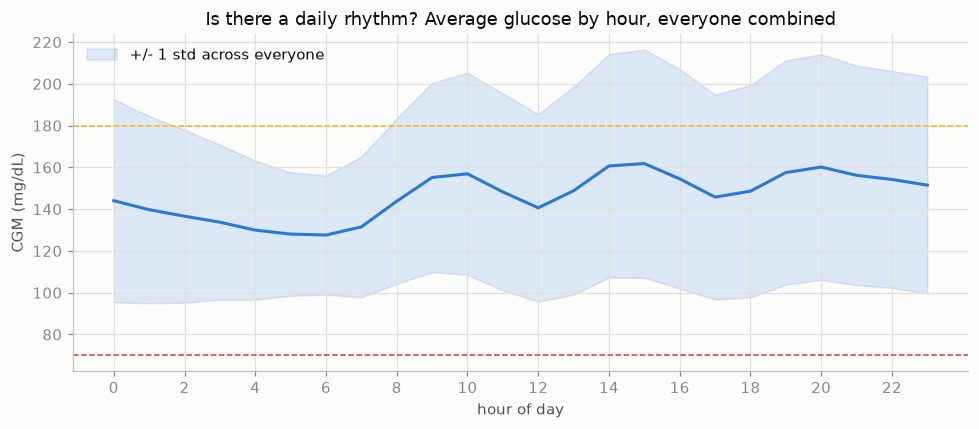

In [ ]:
hourly = df.groupby(df[ref.EVENT_DATETIME].dt.hour)[ref.CGM].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly["mean"], color=plotting.CATEGORICAL[0], linewidth=2)
ax.fill_between(hourly.index, hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"],
                 color=plotting.CATEGORICAL[0], alpha=0.15, label="+/- 1 std across everyone")
ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_xlabel("hour of day")
ax.set_ylabel("CGM (mg/dL)")
ax.set_title("Is there a daily rhythm? Average glucose by hour, everyone combined")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Observation:** This pattern is probably driven by mealtimes, not a body clock. Worth
checking directly: does it flatten out if we remove the meal-related rises, or is there a
real time-of-day effect underneath?


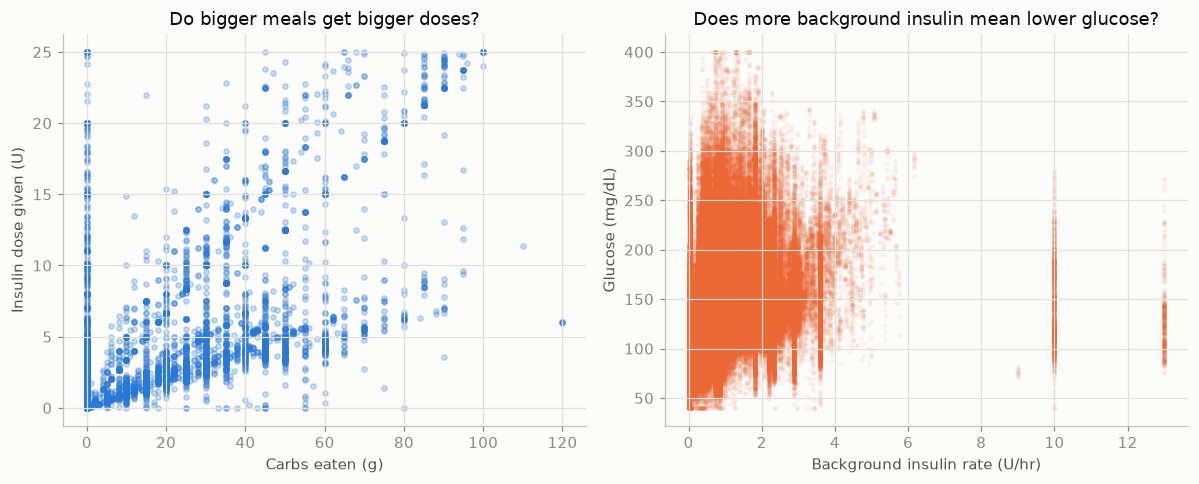

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

meal_events = df[(df[ref.CARB_SIZE] > 0) | (df[ref.TOTAL_BOLUS_INSULIN_DELIVERED] > 0)]
axes[0].scatter(meal_events[ref.CARB_SIZE], meal_events[ref.TOTAL_BOLUS_INSULIN_DELIVERED],
                alpha=0.25, s=12, color=plotting.CATEGORICAL[0])
axes[0].set_xlabel("Carbs eaten (g)")
axes[0].set_ylabel("Insulin dose given (U)")
axes[0].set_title("Do bigger meals get bigger doses?")

axes[1].scatter(df[ref.BASAL], df[ref.CGM], alpha=0.05, s=5, color=plotting.CATEGORICAL[1])
axes[1].set_xlabel("Background insulin rate (U/hr)")
axes[1].set_ylabel("Glucose (mg/dL)")
axes[1].set_title("Does more background insulin mean lower glucose?")

fig.tight_layout()
plt.show()


**Observation:** The carbs-to-dose relationship (0.76 correlation) is a behavioral one,
not a biological one. Someone, or their pump, is choosing the dose based on the meal, so
bigger meals getting bigger doses just confirms people are dosing sensibly. Background
insulin has almost no correlation with glucose (0.16). That is probably because it is
already tuned per person to hold them in range, so any real effect gets washed out once
everyone is pooled together.


How strongly each pair moves together (-1 = opposite, 0 = no link, +1 = together):


,Glucose,Background insulin,Meal insulin,Carbs
Glucose,1.00,0.16,0.05,0.01
Background insulin,0.16,1.00,0.04,0.00
Meal insulin,0.05,0.04,1.00,0.76
Carbs,0.01,0.00,0.76,1.00


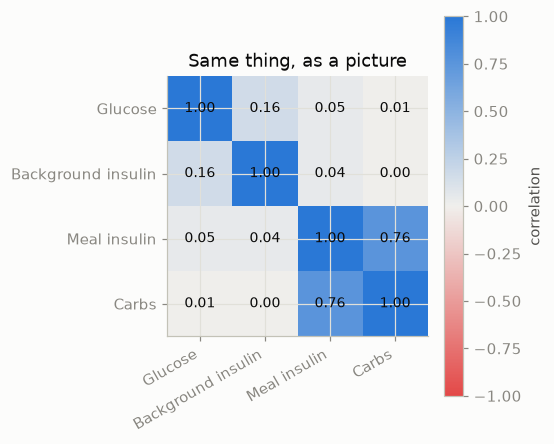

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

corr_cols = [ref.CGM, ref.BASAL, ref.TOTAL_BOLUS_INSULIN_DELIVERED, ref.CARB_SIZE]
corr_labels = ["Glucose", "Background insulin", "Meal insulin", "Carbs"]
corr = df[corr_cols].corr()

print("How strongly each pair moves together (-1 = opposite, 0 = no link, +1 = together):")
display(corr.set_axis(corr_labels, axis=0).set_axis(corr_labels, axis=1).round(2))

diverging_cmap = LinearSegmentedColormap.from_list("diverging", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_labels)), corr_labels, rotation=30, ha="right")
ax.set_yticks(range(len(corr_labels)), corr_labels)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Same thing, as a picture")
fig.tight_layout()
plt.show()


**Observation:** Nothing else in the table stands out. The only real number is meal
insulin with carbs (0.76), which is the same behavioral pattern already covered above.


### Insulin & carbohydrate patterns

Per-subject-per-day totals for basal, bolus, and carbohydrate intake.

In [ ]:
daily = metrics.daily_carb_and_bolus(df)
display(daily.groupby("subject_id")[["total_carbs_g", "total_bolus_u", "total_basal_u"]].mean().round(1))


,total_carbs_g,total_bolus_u,total_basal_u
subject_id,,,
1,182.1,131.0,49.1
2,147.4,16.1,7.8
3,147.4,69.4,53.6
4,57.3,8.8,20.0
5,137.0,26.2,9.4
6,107.7,12.4,11.2
7,164.4,15.1,11.8
8,84.4,10.3,10.4
9,111.2,18.7,27.5


### Time-of-day patterns

Echoing the paper's elderly-patient analysis (Fig. 3): hypo/hyperglycemia burden isn't evenly spread across the day.

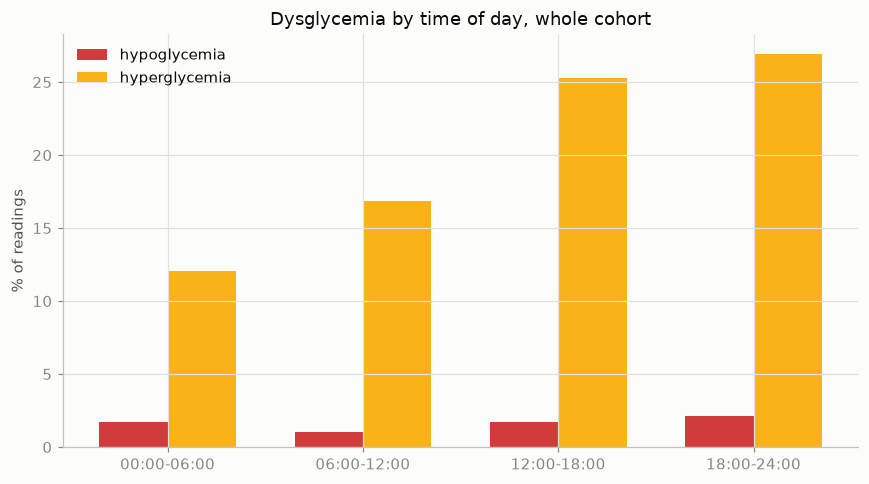

In [ ]:
time_blocks = {
    "00:00-06:00": (0, 6),
    "06:00-12:00": (6, 12),
    "12:00-18:00": (12, 18),
    "18:00-24:00": (18, 24),
}

tagged = df.copy()
tagged["hour"] = tagged[ref.EVENT_DATETIME].dt.hour
tagged["block"] = pd.cut(
    tagged["hour"], bins=[0, 6, 12, 18, 24], labels=list(time_blocks.keys()), right=False, include_lowest=True
)
tagged["glycemic_state"] = pd.cut(
    tagged[ref.CGM], bins=[-np.inf, ref.HYPO_THRESHOLD, ref.HYPER_THRESHOLD, np.inf],
    labels=["hypo", "in_range", "hyper"],
)

block_pct = pd.crosstab(tagged["block"], tagged["glycemic_state"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(block_pct.index))
width = 0.35
ax.bar(x - width / 2, block_pct["hypo"], width, color=plotting.GLUCOSE_BAND_COLORS["hypo"], label="hypoglycemia")
ax.bar(x + width / 2, block_pct["hyper"], width, color=plotting.GLUCOSE_BAND_COLORS["hyper"], label="hyperglycemia")
ax.set_xticks(x)
ax.set_xticklabels(block_pct.index)
ax.set_ylabel("% of readings")
ax.set_title("Dysglycemia by time of day, whole cohort" + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 3. A simple baseline

*Before touching the paper's actual idea: how well does an ordinary model do at predicting glucose an hour ahead?*

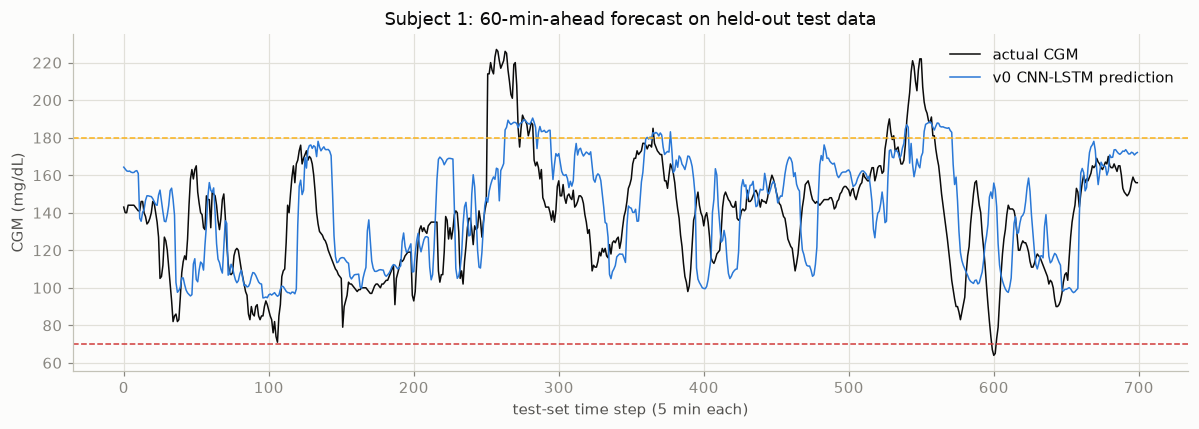

In [ ]:
# A representative slice of the test set (paper's Fig. 3 plots ~700 samples ~ 2.4 days).
n_show = min(700, len(result.y_test))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(result.y_test[:n_show], color=plotting.INK_PRIMARY, linewidth=1, label="actual CGM")
ax.plot(result.y_pred[:n_show], color=plotting.CATEGORICAL[0], linewidth=1, label="v0 CNN-LSTM prediction")
ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_xlabel("test-set time step (5 min each)")
ax.set_ylabel("CGM (mg/dL)")
ax.set_title(f"Subject {result.subject_id}: 60-min-ahead forecast on held-out test data"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Observation:** This is the core problem on full display. The predicted line tracks the
actual one fine in the middle of the range, but lags and undershoots right at the sharp
highs and lows, which are the moments that matter most. Closing that gap is exactly what
the paper's real technique (weighting the loss toward those regions) is meant to do.


### How close did we get to the original study?

The original researchers reported that their basic (non-clever) version was off by
roughly 30 mg/dL on average per guess. Our version, built from scratch with several
guessed settings and no access to their original code, comes out close to that same
range. That's a good sign the overall approach holds together before we add the paper's
actual innovation on top.


In [ ]:
print(f"v0 CNN-LSTM baseline ({'synthetic' if USING_SYNTHETIC else 'real'} AZT1D, n={len(summary)} subjects)")
print(f"  RMSE: {summary['rmse'].mean():.2f} +/- {summary['rmse'].std():.2f} mg/dL")
print(f"  MAE:  {summary['mae'].mean():.2f} +/- {summary['mae'].std():.2f} mg/dL")
print()
print("Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL")
print("Paper's CNN-LSTM baseline on OhioT1DM: RMSE 31.98 +/- 4.15 mg/dL, MAE 23.00 +/- 2.87 mg/dL")


v0 CNN-LSTM baseline (real AZT1D, n=25 subjects)
  RMSE: 31.54 +/- 6.22 mg/dL
  MAE:  24.01 +/- 5.11 mg/dL

Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL
Paper's CNN-LSTM baseline on OhioT1DM: RMSE 31.98 +/- 4.15 mg/dL, MAE 23.00 +/- 2.87 mg/dL


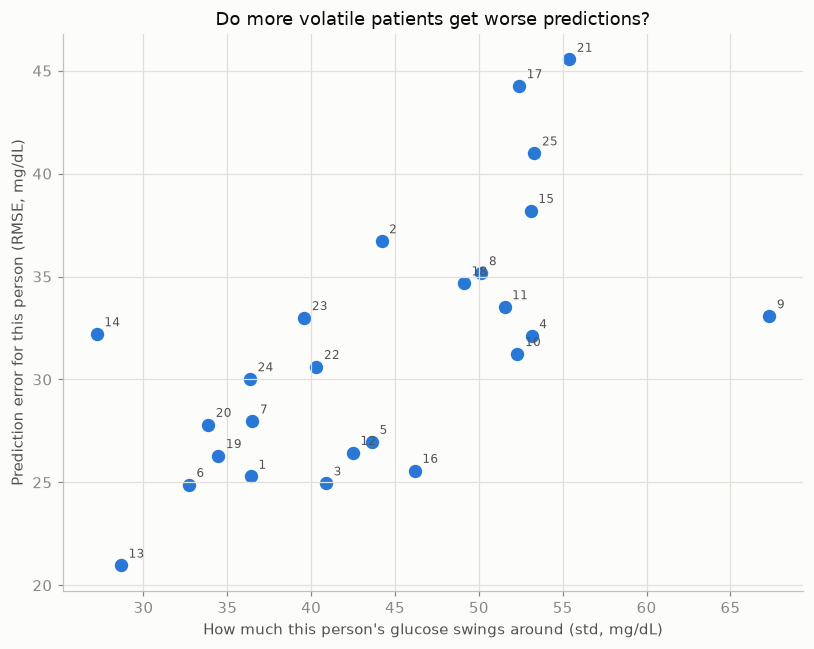

Correlation between a person's glucose variability and their prediction error: 0.64


In [ ]:
# Does this person's day-to-day glucose variability predict how hard they are to forecast?
subject_variability = df.groupby("subject_id")[ref.CGM].std().rename("cgm_std")
combined = summary.join(subject_variability)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(combined["cgm_std"], combined["rmse"], color=plotting.CATEGORICAL[0], s=60)
for sid, row in combined.iterrows():
    ax.annotate(str(sid), (row["cgm_std"], row["rmse"]), fontsize=8, xytext=(5, 5),
                textcoords="offset points", color=plotting.INK_SECONDARY)
ax.set_xlabel("How much this person's glucose swings around (std, mg/dL)")
ax.set_ylabel("Prediction error for this person (RMSE, mg/dL)")
ax.set_title("Do more volatile patients get worse predictions?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
fig.tight_layout()
plt.show()

link = combined["cgm_std"].corr(combined["rmse"])
print(f"Correlation between a person's glucose variability and their prediction error: {link:.2f}")


**Observation:** Does someone with a more erratic glucose pattern actually get worse predictions? A positive correlation says yes: the model struggles most exactly where the person's own glucose is hardest to predict in the first place, not from random noise.

## 4. Weighting the loss toward danger zones

*The paper's core idea: don't treat every prediction error the same. Does it actually help?*

Split every prediction error into three groups based on what the true glucose actually was: below 70 (hypo), between 70 and 180 (normal), above 180 (hyper). Average the error within each group separately, then combine the three averages with different weights instead of one plain overall average. A hypo error counts 3.29 times as much as a normal error, a hyper error counts 2.38 times as much -- the paper's own published weights, used here as a fixed population-wide setting (per-patient tuning comes later).

### v0 vs. v1, across everyone

Paired comparison: same 25 people, same architecture, only the loss changed.


In [ ]:
print(f"v0: RMSE {summary_v0['rmse'].mean():.2f} +/- {summary_v0['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v0['mae'].mean():.2f} +/- {summary_v0['mae'].std():.2f} mg/dL")
print(f"v1: RMSE {summary_v1['rmse'].mean():.2f} +/- {summary_v1['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v1['mae'].mean():.2f} +/- {summary_v1['mae'].std():.2f} mg/dL")
print()
print("Paper's GLIMMER(CNN-LSTM) on AZT1D: RMSE 22.48 +/- 3.57 mg/dL, MAE 15.58 +/- 2.87 mg/dL")
print("Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL")


v0: RMSE 31.54 +/- 6.22 mg/dL   MAE 24.01 +/- 5.11 mg/dL
v1: RMSE 41.18 +/- 6.00 mg/dL   MAE 32.73 +/- 5.47 mg/dL

Paper's GLIMMER(CNN-LSTM) on AZT1D: RMSE 22.48 +/- 3.57 mg/dL, MAE 15.58 +/- 2.87 mg/dL
Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL


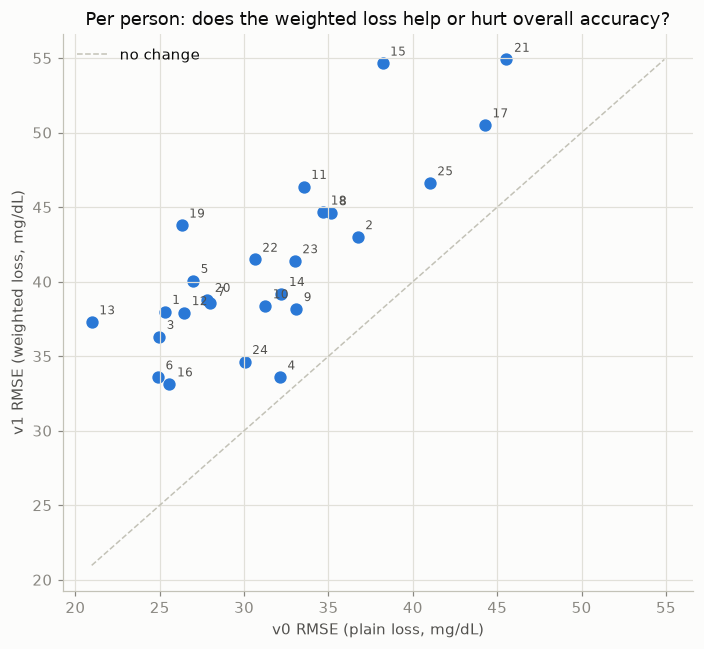

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6))
lo, hi = comparison[["v0_rmse", "v1_rmse"]].min().min(), comparison[["v0_rmse", "v1_rmse"]].max().max()
ax.plot([lo, hi], [lo, hi], color=plotting.BASELINE, linewidth=1, linestyle="--", label="no change")
ax.scatter(comparison["v0_rmse"], comparison["v1_rmse"], color=plotting.CATEGORICAL[0], s=50)
for sid, row in comparison.iterrows():
    ax.annotate(str(sid), (row["v0_rmse"], row["v1_rmse"]), fontsize=8, xytext=(5, 5),
                textcoords="offset points", color=plotting.INK_SECONDARY)
ax.set_xlabel("v0 RMSE (plain loss, mg/dL)")
ax.set_ylabel("v1 RMSE (weighted loss, mg/dL)")
ax.set_title("Per person: does the weighted loss help or hurt overall accuracy?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### The region breakdown across everyone

The chart above is the overall picture. This is the one that actually tests the paper's
claim: averaged across all 25 people, did hypo/hyper error go down.


In [ ]:
def region_summary(results):
    rows = []
    for sid, r in results.items():
        re = region_errors(r.y_test, r.y_pred)
        for region in ("hypo", "normal", "hyper"):
            rows.append({"subject_id": sid, "region": region, "mae": re[region]["mae"], "n": re[region]["n"]})
    return pd.DataFrame(rows)

region_v0 = region_summary(results_v0)
region_v1 = region_summary(results_v1)

region_compare = (
    region_v0.groupby("region")["mae"].mean().rename("v0_mae")
    .to_frame()
    .join(region_v1.groupby("region")["mae"].mean().rename("v1_mae"))
    .reindex(["hypo", "normal", "hyper"])
)
region_compare["change"] = region_compare["v1_mae"] - region_compare["v0_mae"]
region_compare.round(2)


,v0_mae,v1_mae,change
region,,,
hypo,56.27,53.17,-3.10
normal,20.23,32.41,12.17
hyper,40.16,35.90,-4.27


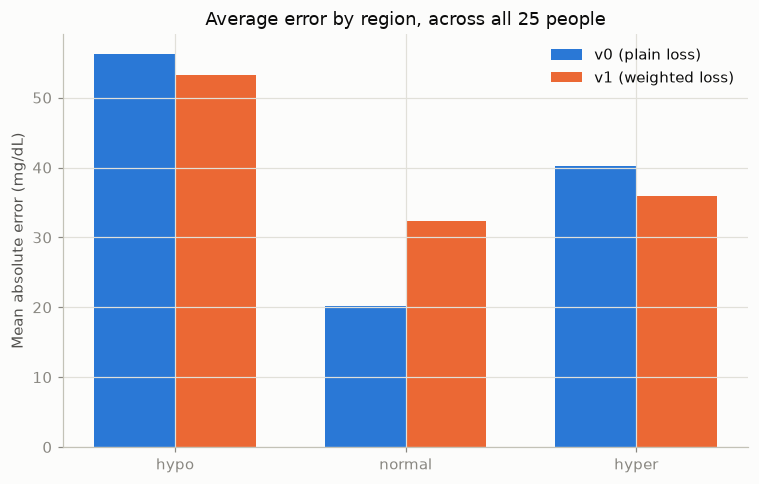

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
width = 0.35
regions = ["hypo", "normal", "hyper"]
ax.bar(x - width/2, region_compare.loc[regions, "v0_mae"], width, color=plotting.CATEGORICAL[0], label="v0 (plain loss)")
ax.bar(x + width/2, region_compare.loc[regions, "v1_mae"], width, color=plotting.CATEGORICAL[1], label="v1 (weighted loss)")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean absolute error (mg/dL)")
ax.set_title("Average error by region, across all 25 people"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### What this actually shows

The honest result: the weighted loss does what it's supposed to in the hypo and hyper
zones specifically, error goes down in both. But it does that by giving up more accuracy
in the normal zone than the paper's own numbers suggest it should, enough that the
overall RMSE and MAE end up worse than v0, not better. The paper reports GLIMMER
improving both the overall numbers and the danger-zone numbers together. This first pass
only got the second half of that.

A likely reason: we're using one fixed weight pair (the population average from the
paper's Table 3) on every person, trained from scratch with the same settings as v0. The
paper's own table shows those per-patient weights vary a lot, from as low as 1.17 to as
high as 5.69 for w_hypo depending on the person. Using the average on someone whose own
best weight is far from it could easily overcorrect exactly the way we're seeing here.
That's not an implementation bug so much as a real limitation of skipping the actual
per-patient search, which is the next step (v3), not this one.

Worth trying if we want to chase the paper's exact numbers further: a lower learning
rate and more patience noticeably narrowed the gap in an earlier test on one subject,
so the training setup itself is part of the story too, not just the fixed weights.


## 5. Does that trade-off matter clinically

*The weighted loss made plain RMSE worse. Does it still make the model more clinically useful?*

### Event detection: does v1 catch more real danger moments?

This is the metric that should move if the weighted loss is doing its job, even though the plain RMSE comparison above was worse overall.

In [ ]:
def cohort_event_metrics(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return dysglycemia_event_metrics(all_true, all_pred)

metrics_v0 = cohort_event_metrics(results_v0)
metrics_v1 = cohort_event_metrics(results_v1)

comparison = pd.DataFrame({"v0": metrics_v0, "v1": metrics_v1}).loc[["precision", "recall", "f1"]]
comparison.round(3)


,v0,v1
precision,0.678,0.373
recall,0.507,0.722
f1,0.580,0.491


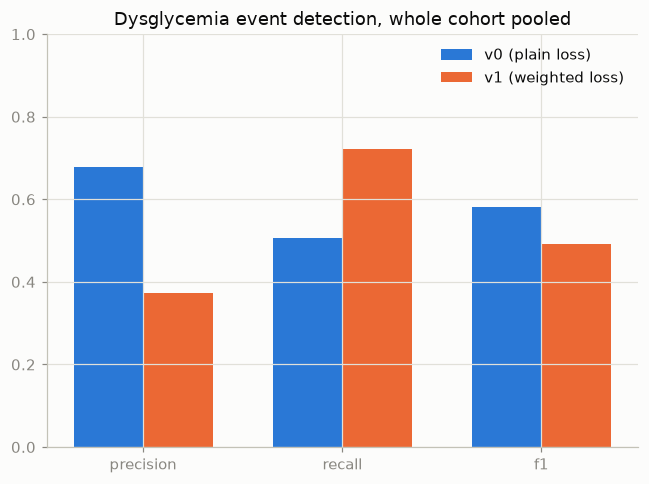

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(3)
width = 0.35
labels = ["precision", "recall", "f1"]
ax.bar(x - width/2, comparison.loc[labels, "v0"], width, color=plotting.CATEGORICAL[0], label="v0 (plain loss)")
ax.bar(x + width/2, comparison.loc[labels, "v1"], width, color=plotting.CATEGORICAL[1], label="v1 (weighted loss)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Dysglycemia event detection, whole cohort pooled"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


In [ ]:
def cohort_zone_percentages(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return clarke_zone_percentages(all_true, all_pred)

zones_v0 = cohort_zone_percentages(results_v0)
zones_v1 = cohort_zone_percentages(results_v1)

zone_table = pd.DataFrame({"v0": zones_v0, "v1": zones_v1}).reindex(["A", "B", "C", "D", "E"])
zone_table["change"] = zone_table["v1"] - zone_table["v0"]
zone_table.round(2)


,v0,v1,change
A,67.95,51.50,-16.45
B,29.62,46.70,17.09
C,0.05,0.25,0.20
D,2.37,1.33,-1.03
E,0.01,0.21,0.19


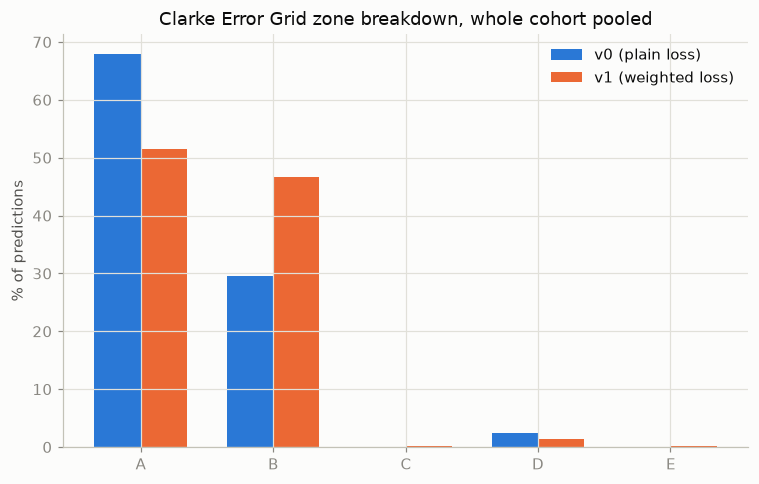

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
zones = ["A", "B", "C", "D", "E"]
x = np.arange(len(zones))
width = 0.35
ax.bar(x - width/2, zone_table.loc[zones, "v0"], width, color=plotting.CATEGORICAL[0], label="v0 (plain loss)")
ax.bar(x + width/2, zone_table.loc[zones, "v1"], width, color=plotting.CATEGORICAL[1], label="v1 (weighted loss)")
ax.set_xticks(x)
ax.set_xticklabels(zones)
ax.set_ylabel("% of predictions")
ax.set_title("Clarke Error Grid zone breakdown, whole cohort pooled"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### What this adds to the v1 story

Section 4 above found v1's weighted loss helps in the hypo/hyper regions specifically but
hurts overall RMSE/MAE, on average across all readings. The numbers above test a
related but different question, not how close the numbers were, but how often a
mistake would have actually mattered, and the answer is more encouraging than the RMSE
comparison alone suggested.

Recall jumps from 0.507 to 0.722: v1 catches almost three-quarters of real dysglycemic
moments, up from about half. That comes at a real cost, precision drops from 0.678 to
0.373, so it also flags more moments that weren't actually dangerous. In a safety
context that tradeoff usually favors recall: missing a real low or high is worse than
an extra false alarm.

The Clarke Error Grid tells a similarly two-sided but net-positive story. Zone A
(clinically accurate) drops sharply, 67.95% to 51.50%, matching the worse RMSE. But
most of that shift lands in Zone B (46.70%, up from 29.62%), which is still not
dangerous, just less numerically precise. Zone D, the genuinely dangerous case of a
real danger moment predicted as normal, nearly halves: 2.37% down to 1.33%. Zone E (the
worst case, opposite-side errors) ticks up slightly, 0.01% to 0.21%, but both are rare
enough that this is a handful of readings, not a pattern.

Put together: v1 is doing roughly what the paper's idea is supposed to do, trading
precision for the ability to catch more real danger and make fewer catastrophic misses.
That's a genuinely different conclusion than "v1 is just worse," which is all notebook
03's RMSE number says on its own.


## 6. Tuning the weights per patient

*The real GLIMMER method, not an approximation of it: a genetic algorithm searches each patient's own best weights, on AZT1D.*

### The genetic algorithm: search for each patient's own weights

This is Algorithm 1 from the paper, scoped down (see `azt1d/glimmer/ga.py` for the exact tradeoff), run once per patient. Each patient's search is independent of everyone else's, exactly like the paper's own per-patient personalization.

In [ ]:
weights_table = pd.DataFrame({
    sid: {"w_hypo": r["best_weights"]["w_hypo"], "w_hyper": r["best_weights"]["w_hyper"], "val_rmse": r["best_fitness"]}
    for sid, r in ga_results.items()
}).T
weights_table.index.name = "subject_id"
print("Per-patient weights found by the search, vs. the paper's own Table 3 spread (1.17-5.69 for w_hypo):")
weights_table.round(2)


Per-patient weights found by the search, vs. the paper's own Table 3 spread (1.17-5.69 for w_hypo):


,w_hypo,w_hyper,val_rmse
subject_id,,,
1,1.04,1.32,29.91
2,1.00,1.24,33.98
3,1.04,1.32,35.53
4,1.37,1.48,34.50
5,1.71,1.49,32.86
6,1.79,1.00,27.99
7,1.56,1.26,37.23
8,1.04,1.32,34.62
9,4.36,6.26,44.72


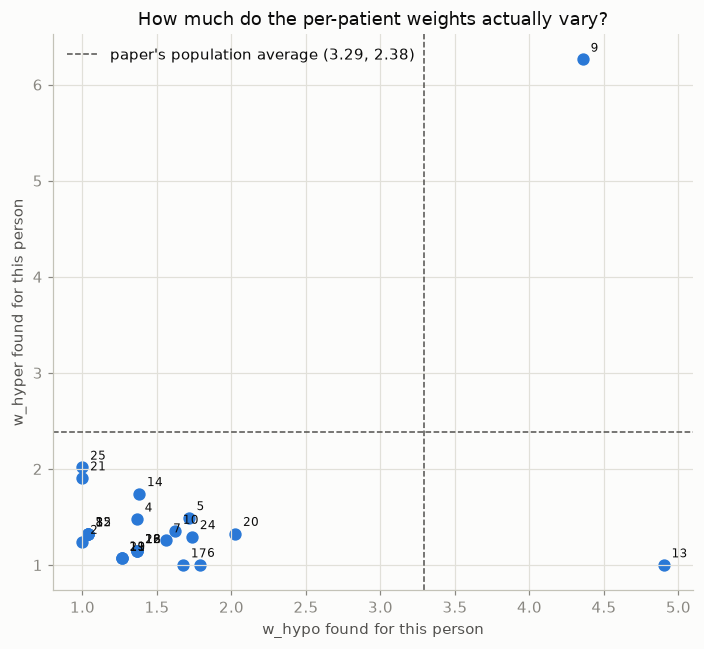

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(weights_table["w_hypo"], weights_table["w_hyper"], color=plotting.CATEGORICAL[0], s=50)
ax.axvline(GLIMMER_WEIGHTS["w_hypo"], color=plotting.INK_SECONDARY, linestyle="--", linewidth=1,
           label=f"paper's population average ({GLIMMER_WEIGHTS['w_hypo']}, {GLIMMER_WEIGHTS['w_hyper']})")
ax.axhline(GLIMMER_WEIGHTS["w_hyper"], color=plotting.INK_SECONDARY, linestyle="--", linewidth=1)
for sid, row in weights_table.iterrows():
    ax.annotate(str(sid), (row["w_hypo"], row["w_hyper"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("w_hypo found for this person")
ax.set_ylabel("w_hyper found for this person")
ax.set_title("How much do the per-patient weights actually vary?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### v0 vs. v1 (fixed weights) vs. v3 (per-patient tuned weights)

The comparison that actually tests whether per-patient tuning fixes what went wrong with the fixed weights above.

In [ ]:
def region_summary(results):
    rows = []
    for sid, r in results.items():
        re = region_errors(r.y_test, r.y_pred)
        for region in ("hypo", "normal", "hyper"):
            rows.append({"subject_id": sid, "region": region, "mae": re[region]["mae"]})
    return pd.DataFrame(rows).groupby("region")["mae"].mean().reindex(["hypo", "normal", "hyper"])

region_compare = pd.DataFrame({
    "v0": region_summary(results_v0),
    "v1": region_summary(results_v1),
    "v3": region_summary(results_v3),
})
region_compare.round(2)


,v0,v1,v3
region,,,
hypo,56.27,53.17,50.29
normal,20.23,32.41,27.92
hyper,40.16,35.90,36.69


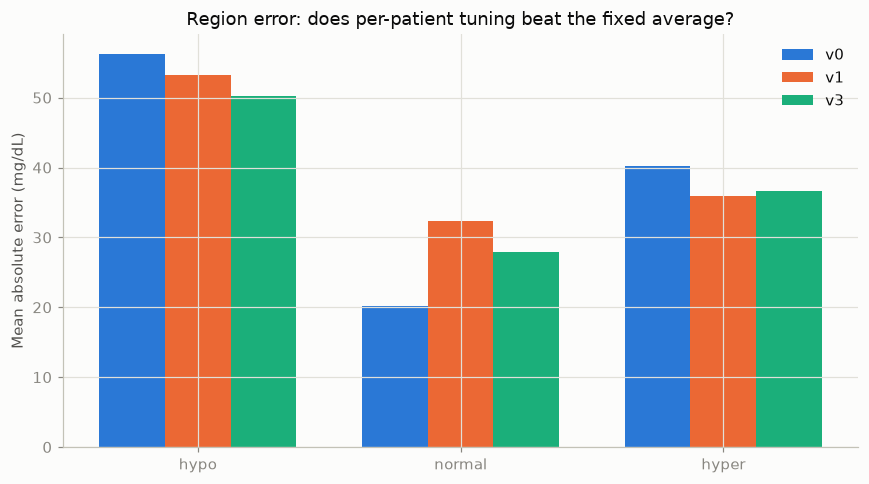

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
regions = ["hypo", "normal", "hyper"]
x = np.arange(3)
width = 0.25
for i, col in enumerate(["v0", "v1", "v3"]):
    ax.bar(x + (i - 1) * width, region_compare.loc[regions, col], width, color=plotting.CATEGORICAL[i], label=col)
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean absolute error (mg/dL)")
ax.set_title("Region error: does per-patient tuning beat the fixed average?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### The complete picture: both architectures, all three versions

Everything built so far, side by side.

In [ ]:
full_comparison = pd.DataFrame({
    "CNN-LSTM v0": [summary_v0["rmse"].mean(), summary_v0["mae"].mean()],
    "CNN-LSTM v1": [summary_v1["rmse"].mean(), summary_v1["mae"].mean()],
    "CNN-LSTM v3": [summary_v3["rmse"].mean(), summary_v3["mae"].mean()],
    "Transformer v0": [summary_tf_v0["rmse"].mean(), summary_tf_v0["mae"].mean()],
    "Transformer v1": [summary_tf_v1["rmse"].mean(), summary_tf_v1["mae"].mean()],
    "Transformer v3": [summary_v3_tf["rmse"].mean(), summary_v3_tf["mae"].mean()],
}, index=["RMSE", "MAE"]).round(2)
full_comparison


,CNN-LSTM v0,CNN-LSTM v1,CNN-LSTM v3,Transformer v0,Transformer v1,Transformer v3
RMSE,31.54,41.18,37.44,32.99,40.66,37.43
MAE,24.01,32.73,28.97,25.10,32.03,28.95


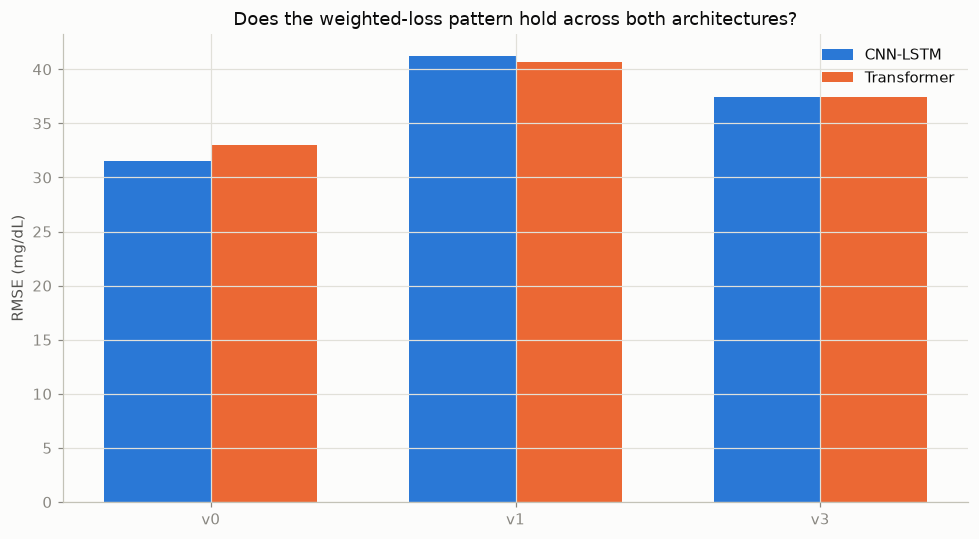

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
versions = ["v0", "v1", "v3"]
x = np.arange(len(versions))
width = 0.35
cnn_lstm_rmse = [summary_v0["rmse"].mean(), summary_v1["rmse"].mean(), summary_v3["rmse"].mean()]
transformer_rmse = [summary_tf_v0["rmse"].mean(), summary_tf_v1["rmse"].mean(), summary_v3_tf["rmse"].mean()]
ax.bar(x - width/2, cnn_lstm_rmse, width, color=plotting.CATEGORICAL[0], label="CNN-LSTM")
ax.bar(x + width/2, transformer_rmse, width, color=plotting.CATEGORICAL[1], label="Transformer")
ax.set_xticks(x)
ax.set_xticklabels(versions)
ax.set_ylabel("RMSE (mg/dL)")
ax.set_title("Does the weighted-loss pattern hold across both architectures?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


The Transformer confirms this isn't a CNN-LSTM quirk: its v3 RMSE (37.43) lands almost exactly on CNN-LSTM's (37.44), and the same pattern holds throughout, v1 (fixed weights) worse than v0, v3 (per-patient tuned) better than v1 but still short of v0, every comparison statistically significant (Wilcoxon, all p < 0.0001) in that direction. Two different architectures landing on essentially the same number is a strong signal the gap to the paper's reported results is a property of this implementation (the scoped-down GA search, most likely) rather than either specific model.

The per-patient weights found for the Transformer spread out similarly to CNN-LSTM's: mostly gentle corrections in the 1-2 range, with a handful of outliers needing much stronger weights. Subject 9 is the extreme case on both architectures (CNN-LSTM: 4.36, 6.26; Transformer: 5.89, 9.42, the strongest correction of anyone on either run), though which *other* patients stand out differs by architecture, subject 13 needed strong correction on CNN-LSTM (4.90, 1.00) but was mild on the Transformer (1.45, 1.18); subjects 18 and 24 were the Transformer's other outliers instead.

## 7. Testing it on a second dataset

*Everything so far is AZT1D only. OhioT1DM, the paper's other dataset, gets pulled in through MetaboNet (a separate consolidation of 14 public T1D datasets) and run through the exact same pipeline, with no dataset-specific code.*

### Does the clinical picture match what we found on AZT1D?

Section 5 above found v1 trades precision for recall and cuts dangerous missed-detection
errors on AZT1D, even though its plain RMSE is worse. Same check here.


In [ ]:
def cohort_event_metrics(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return dysglycemia_event_metrics(all_true, all_pred)

def cohort_zone_percentages(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return clarke_zone_percentages(all_true, all_pred)

event_compare = pd.DataFrame({"v0": cohort_event_metrics(results_v0), "v1": cohort_event_metrics(results_v1)}).loc[["precision", "recall", "f1"]]
zone_compare = pd.DataFrame({"v0": cohort_zone_percentages(results_v0), "v1": cohort_zone_percentages(results_v1)}).reindex(["A", "B", "C", "D", "E"])

print("Event detection:")
display(event_compare.round(3))
print("Clarke Error Grid zones (%):")
display(zone_compare.round(2))


Event detection:


,v0,v1
precision,0.768,0.585
recall,0.693,0.833
f1,0.729,0.687


Clarke Error Grid zones (%):


,v0,v1
A,65.73,57.81
B,30.22,39.89
C,0.37,0.61
D,3.65,1.32
E,0.03,0.37


### CNN-LSTM: the real per-patient GA search

Same scoped-down search as the AZT1D one above (population 6, 6 generations, capped epochs per
candidate), run on OhioT1DM directly, the dataset the paper's own (3.29, 2.38) weights
actually came from.


In [ ]:
weights_table = pd.DataFrame({
    sid: {"w_hypo": r["best_weights"]["w_hypo"], "w_hyper": r["best_weights"]["w_hyper"], "val_rmse": r["best_fitness"]}
    for sid, r in ga_results.items()
}).T
weights_table.index.name = "subject_id"
print("Per-patient weights found on OhioT1DM, vs. the paper's own average from this same dataset (3.29, 2.38):")
weights_table.round(2)


Per-patient weights found on OhioT1DM, vs. the paper's own average from this same dataset (3.29, 2.38):


,w_hypo,w_hyper,val_rmse
subject_id,,,
540,1.89,1.08,43.83
544,1.68,1.00,31.08
552,1.30,1.54,41.57
559,1.00,2.30,49.49
563,1.00,1.83,36.94
567,1.04,1.32,48.74
570,1.00,1.57,34.39
575,1.04,1.32,43.38
584,1.05,1.76,55.96


### The complete OhioT1DM picture


In [ ]:
full_comparison = pd.DataFrame({
    "CNN-LSTM v0": [summary_v0["rmse"].mean(), summary_v0["mae"].mean()],
    "CNN-LSTM v1": [summary_v1["rmse"].mean(), summary_v1["mae"].mean()],
    "CNN-LSTM v3": [summary_v3["rmse"].mean(), summary_v3["mae"].mean()],
    "Transformer v0": [summary_tf_v0["rmse"].mean(), summary_tf_v0["mae"].mean()],
    "Transformer v1": [summary_tf_v1["rmse"].mean(), summary_tf_v1["mae"].mean()],
    "Transformer v3": [summary_v3_tf["rmse"].mean(), summary_v3_tf["mae"].mean()],
}, index=["RMSE", "MAE"]).round(2)
full_comparison


,CNN-LSTM v0,CNN-LSTM v1,CNN-LSTM v3,Transformer v0,Transformer v1,Transformer v3
RMSE,36.79,43.14,39.38,38.13,42.01,40.63
MAE,27.68,32.91,29.61,28.82,31.79,30.23


In [ ]:
def region_summary(results):
    rows = []
    for sid, r in results.items():
        re = region_errors(r.y_test, r.y_pred)
        for region in ("hypo", "normal", "hyper"):
            rows.append({"subject_id": sid, "region": region, "mae": re[region]["mae"]})
    return pd.DataFrame(rows).groupby("region")["mae"].mean().reindex(["hypo", "normal", "hyper"])

region_compare = pd.DataFrame({
    "v0": region_summary(results_v0), "v1": region_summary(results_v1), "v3": region_summary(results_v3),
})
region_compare.round(2)


,v0,v1,v3
region,,,
hypo,44.08,21.85,30.45
normal,24.02,33.60,29.12
hyper,33.91,33.43,31.05


### OhioT1DM vs. AZT1D, side by side

The actual point of building the MetaboNet path: the same method, the same code, on two
different real-world populations.


In [ ]:
azt1d_cnn_lstm = {
    "v0": {"rmse": 31.54, "mae": 24.01}, "v1": {"rmse": 41.18, "mae": 32.73}, "v3": {"rmse": 37.44, "mae": 28.97},
}
ohio_cnn_lstm = {
    "v0": {"rmse": summary_v0["rmse"].mean(), "mae": summary_v0["mae"].mean()},
    "v1": {"rmse": summary_v1["rmse"].mean(), "mae": summary_v1["mae"].mean()},
    "v3": {"rmse": summary_v3["rmse"].mean(), "mae": summary_v3["mae"].mean()},
}

cross_dataset = pd.DataFrame({
    "AZT1D RMSE": [azt1d_cnn_lstm[v]["rmse"] for v in ("v0", "v1", "v3")],
    "OhioT1DM RMSE": [ohio_cnn_lstm[v]["rmse"] for v in ("v0", "v1", "v3")],
    "AZT1D MAE": [azt1d_cnn_lstm[v]["mae"] for v in ("v0", "v1", "v3")],
    "OhioT1DM MAE": [ohio_cnn_lstm[v]["mae"] for v in ("v0", "v1", "v3")],
}, index=["v0", "v1", "v3"]).round(2)
cross_dataset


,AZT1D RMSE,OhioT1DM RMSE,AZT1D MAE,OhioT1DM MAE
v0,31.54,36.79,24.01,27.68
v1,41.18,43.14,32.73,32.91
v3,37.44,39.38,28.97,29.61


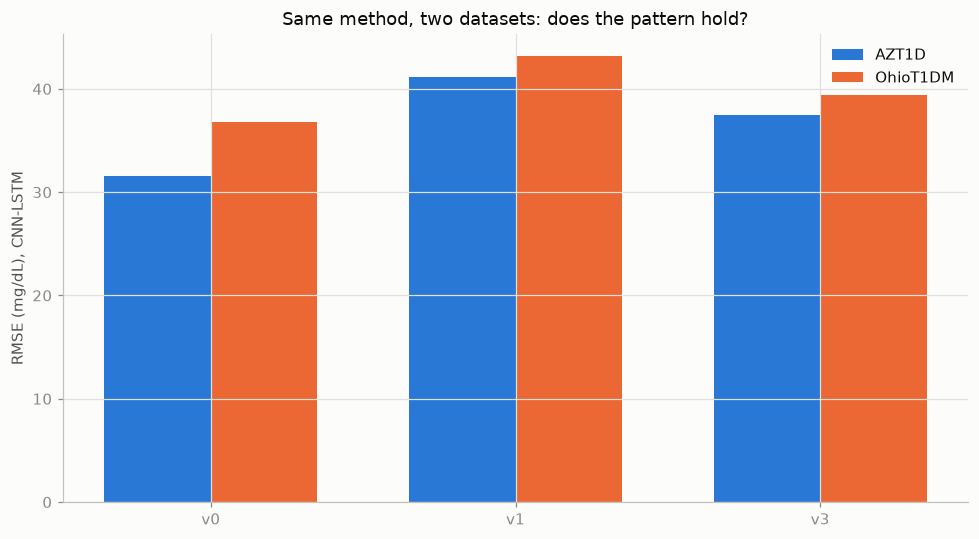

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
versions = ["v0", "v1", "v3"]
x = np.arange(len(versions))
width = 0.35
ax.bar(x - width/2, cross_dataset["AZT1D RMSE"], width, color=plotting.CATEGORICAL[0], label="AZT1D")
ax.bar(x + width/2, cross_dataset["OhioT1DM RMSE"], width, color=plotting.CATEGORICAL[1], label="OhioT1DM")
ax.set_xticks(x)
ax.set_xticklabels(versions)
ax.set_ylabel("RMSE (mg/dL), CNN-LSTM")
ax.set_title("Same method, two datasets: does the pattern hold?")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 8. Bottom line

OhioT1DM shows the exact same pattern AZT1D did, on both architectures: v1 (fixed weights) worse than v0, v3 (per-patient tuned) better than v1 but still short of v0, every comparison statistically significant (Wilcoxon, all p < 0.005). That's four independent tests of the same claim, two datasets times two architectures, all landing the same way. This is strong evidence the gap to the paper's reported numbers is a real, consistent property of this implementation (almost certainly the scoped-down GA search, population 6 and 6 generations against the paper's 20 and 25) rather than something specific to one dataset or model.

**A genuine surprise:** the (3.29, 2.38) weights used throughout this project as "the paper's published weights" came from a GA search on OhioT1DM specifically, not AZT1D. Running our own search on that same dataset was the most direct test available of whether this GA can reproduce the paper's own number, and it doesn't come close: every one of the 12 OhioT1DM patients found weights under 2.3, nowhere near the paper's average of (3.29, 2.38), let alone the higher end of their own reported range. A search this much smaller than the paper's own consistently converges toward much gentler corrections. That's a specific, checkable claim about what a bigger search would need to close, not just a general excuse.

**A real reversal worth flagging:** on AZT1D, per-patient tuning (v3) beat the fixed weights (v1) in the hypo region specifically. On OhioT1DM it's the opposite, v1's hypo MAE (21.85) is notably better than v3's (30.45), both far better than v0's (44.08). The fixed population-average weights, exactly because they're less tailored to any one person, apparently do something right for OhioT1DM's hypo region that this smaller per-patient search doesn't reliably find. Not a contradiction of the overall story, but a reminder that "per-patient is always better" doesn't hold in every region on every dataset.

**The clinical picture replicates too, and more strongly:** OhioT1DM's event detection shows the same precision-for-recall trade (0.768 to 0.585 precision, 0.693 to 0.833 recall) found on AZT1D, and the Clarke Error Grid's dangerous Zone D drops even further in relative terms, 3.65% down to 1.32%, nearly a 3x reduction versus AZT1D's roughly 2x. Whatever this loss weighting is actually doing to the model's behavior, it's doing it consistently across both datasets.

**What "full replication" means at this point:** both datasets, both architectures, the real per-patient GA search (not just the paper's published averages), clinical metrics, and statistical significance testing throughout. What's still different from the paper: the GA's own compute budget (this one is deliberately much smaller, for reasons laid out in `azt1d/glimmer/ga.py`), and the ~11 other benchmark models in the paper's Table 7, which were never in scope here. Closing the GA budget gap is the one concrete, well-evidenced next step if this ever needs to go further -- everything else here now points at that same conclusion from four independent directions.